In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [2]:
alpha = 0.015
total_steps = 250

A = np.diag(np.array([1, 100]))

In [3]:
def loss_function(theta):
    return (0.5)*theta.T@A@theta

def grad_function(theta):
    grad = A@theta
    return grad

def sgd_theta_update(theta, alpha):
    new_update = alpha*grad_function(theta)
    new_theta = theta - new_update
    return new_theta

def sgd_theta_with_momentum_update(theta, prev_v, alpha, beta):
    curr_v = beta*prev_v + alpha*grad_function(theta)
    new_theta = theta - curr_v
    new_v = curr_v
    return new_theta, curr_v

def sgd_theta_with_nesterov_momentum_update(theta, prev_v, alpha, beta):
    theta_lookup = theta + beta*prev_v
    curr_v = beta*prev_v - alpha*grad_function(theta_lookup)
    new_theta = theta + curr_v
    new_v = curr_v
    return new_theta, new_v

def cosine_similarity(a, b):
    a = np.array(a)
    b = np.array(b)
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))
    

In [4]:
def optimization(theta0, method=None, alpha=None, beta=None):
    # Optimization
    cosine_similarity_hist = []
    
    curr_theta = theta0

    prev_grad = []
    prev_v = 0
    for _ in range(total_steps):    
        if method == "sgd":
            curr_theta = sgd_theta_update(curr_theta, alpha)
            curr_grad = grad_function(curr_theta)
            if (len(prev_grad) != 0):
                curr_cosine_similarity = cosine_similarity(curr_grad, prev_grad)
                cosine_similarity_hist.append(curr_cosine_similarity)
            prev_grad = curr_grad
        elif method == "momentum":
            curr_theta, curr_v = sgd_theta_with_momentum_update(curr_theta, prev_v, alpha, beta)
            curr_grad = grad_function(curr_theta)
            if (len(prev_grad) != 0):
                curr_cosine_similarity = cosine_similarity(curr_grad, prev_grad)
                cosine_similarity_hist.append(curr_cosine_similarity)
            prev_grad = curr_grad
            prev_v = curr_v
        elif method == "nesterov":
            curr_theta, curr_v = sgd_theta_with_nesterov_momentum_update(curr_theta, prev_v, alpha, beta)
            curr_grad = grad_function(curr_theta)
            if (len(prev_grad) != 0):
                curr_cosine_similarity = cosine_similarity(curr_grad, prev_grad)
                cosine_similarity_hist.append(curr_cosine_similarity)
            prev_grad = curr_grad
            prev_v = curr_v
    return cosine_similarity_hist

In [5]:
theta0 = np.array([5, 5])
theta_star = np.array([0.0, 0.0])

In [6]:
cosine_similarity_sgd_hist = optimization(theta0, method="sgd", alpha=0.015)
cosine_similarity_momentum_hist = optimization(theta0, method="momentum", alpha=0.015, beta=0.9)
cosine_similarity_nesterov_hist = optimization(theta0, method="nesterov", alpha=0.015, beta=0.9)

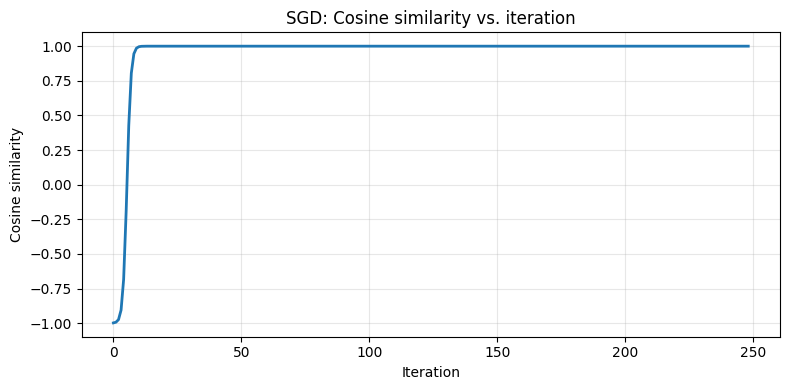

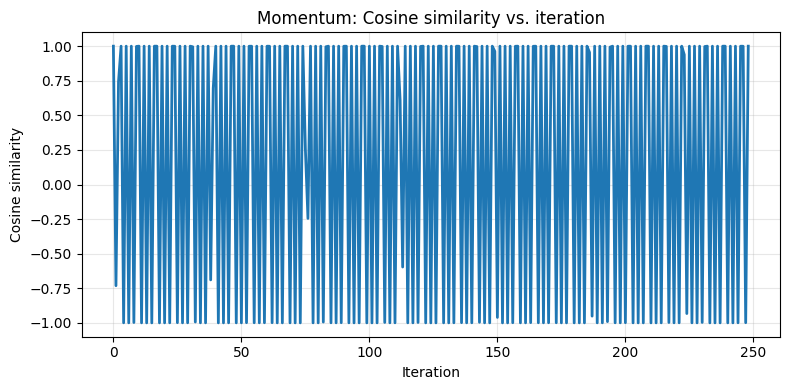

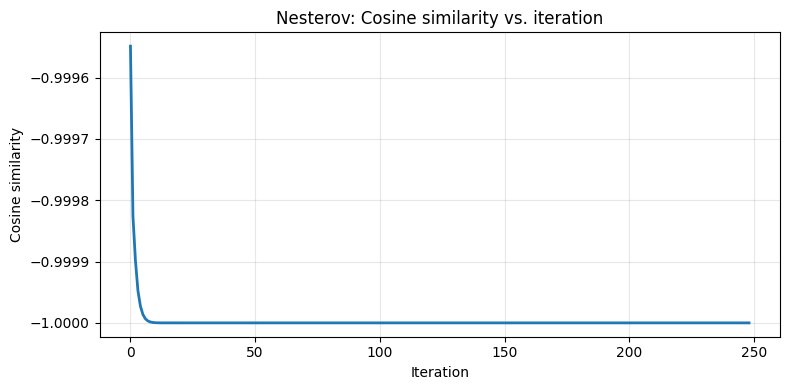

In [7]:
hists = {
    "SGD": cosine_similarity_sgd_hist,
    "Momentum": cosine_similarity_momentum_hist,
    "Nesterov": cosine_similarity_nesterov_hist,
}

min_len = min(len(v) for v in hists.values())

for name, hist in hists.items():
    plt.figure(figsize=(8, 4))  # New figure for each plot
    
    y = np.asarray(hist[:min_len], dtype=float)
    plt.plot(np.arange(min_len), y, linewidth=2)
    
    plt.xlabel("Iteration")
    plt.ylabel("Cosine similarity")
    plt.title(f"{name}: Cosine similarity vs. iteration")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

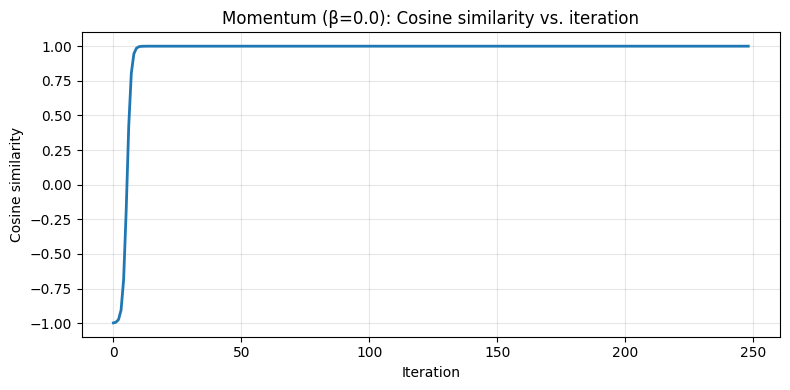

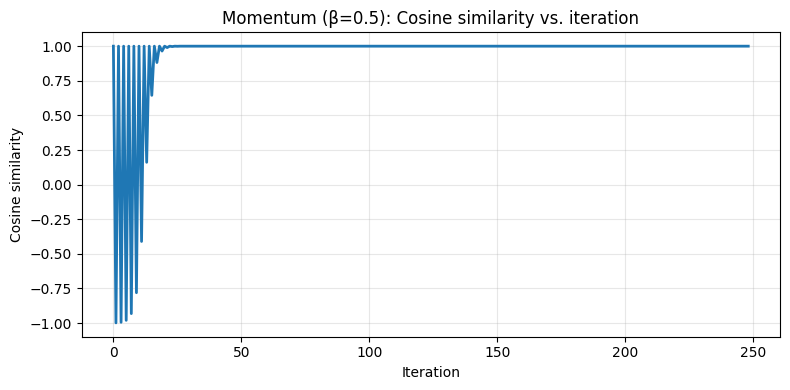

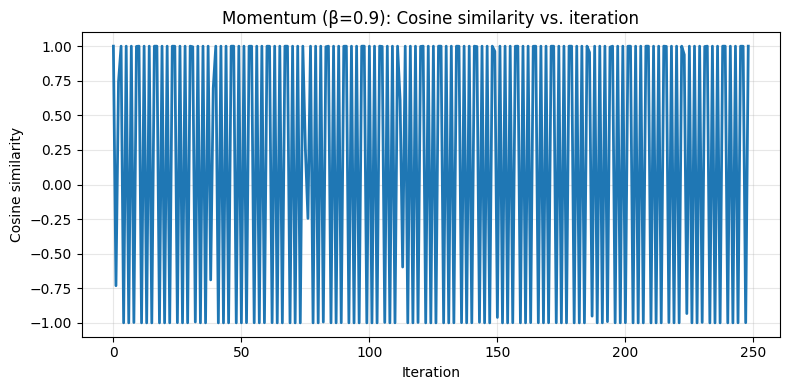

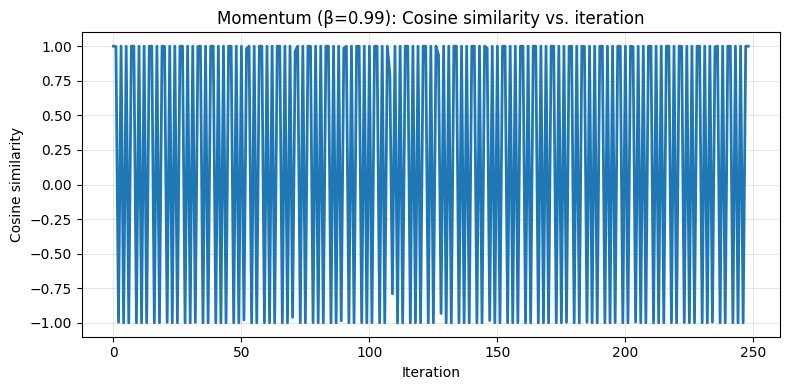

In [8]:
# Momentum
betas = [0.0, 0.5, 0.9, 0.99]

hists = {}

for beta in betas:
    hist = optimization(theta0, method="momentum", alpha=0.015, beta=beta)
    hists[f"Momentum (β={beta})"] = hist

min_len = min(len(v) for v in hists.values())

for name, hist in hists.items():
    plt.figure(figsize=(8, 4))
    
    y = np.asarray(hist[:min_len], dtype=float)
    plt.plot(np.arange(min_len), y, linewidth=2)
    
    plt.xlabel("Iteration")
    plt.ylabel("Cosine similarity")
    plt.title(f"{name}: Cosine similarity vs. iteration")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

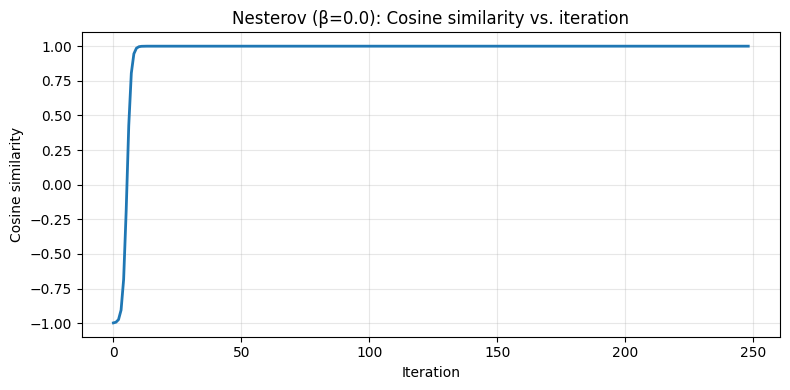

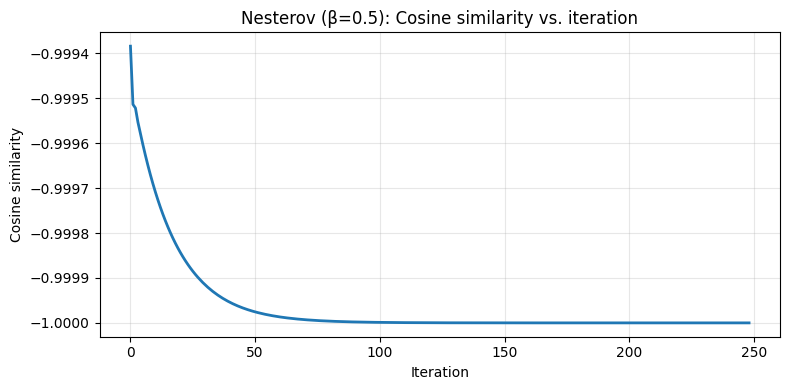

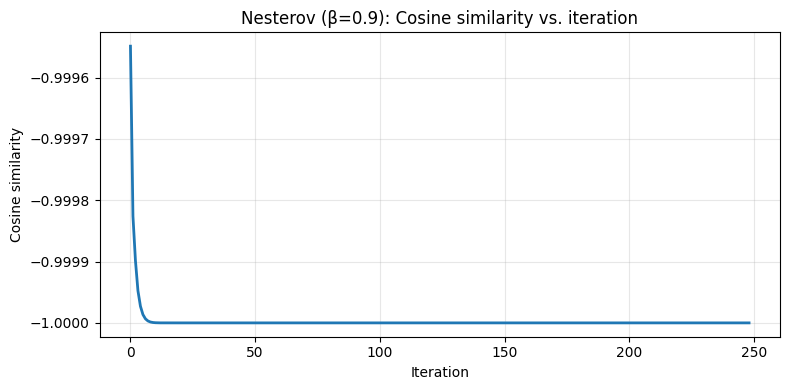

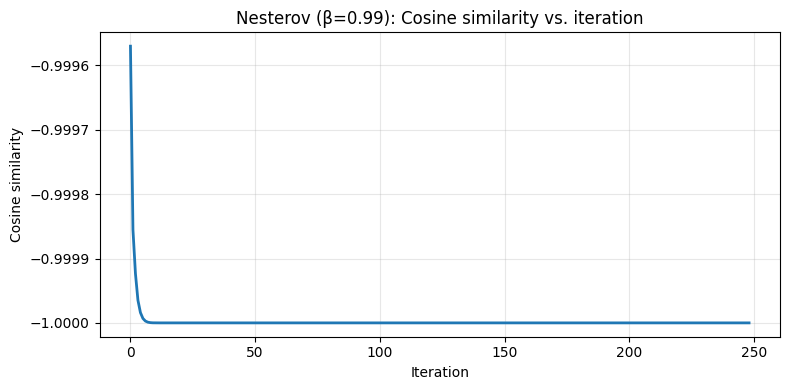

In [9]:
betas = [0.0, 0.5, 0.9, 0.99]

hists = {}

for beta in betas:
    hist = optimization(theta0, method="nesterov", alpha=0.015, beta=beta)
    hists[f"Nesterov (β={beta})"] = hist

min_len = min(len(v) for v in hists.values())

for name, hist in hists.items():
    plt.figure(figsize=(8, 4))
    
    y = np.asarray(hist[:min_len], dtype=float)
    plt.plot(np.arange(min_len), y, linewidth=2)
    
    plt.xlabel("Iteration")
    plt.ylabel("Cosine similarity")
    plt.title(f"{name}: Cosine similarity vs. iteration")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

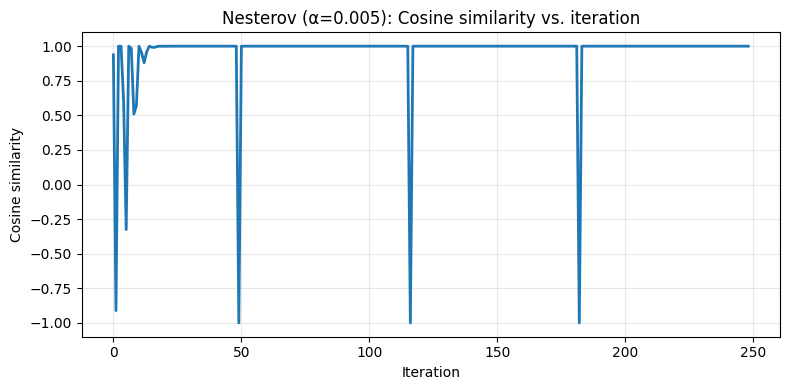

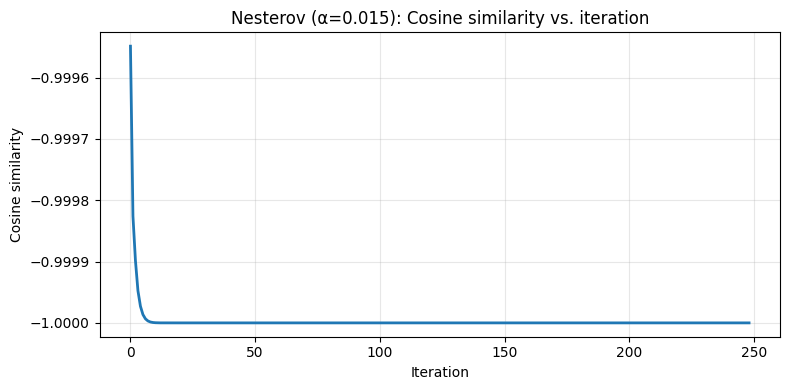

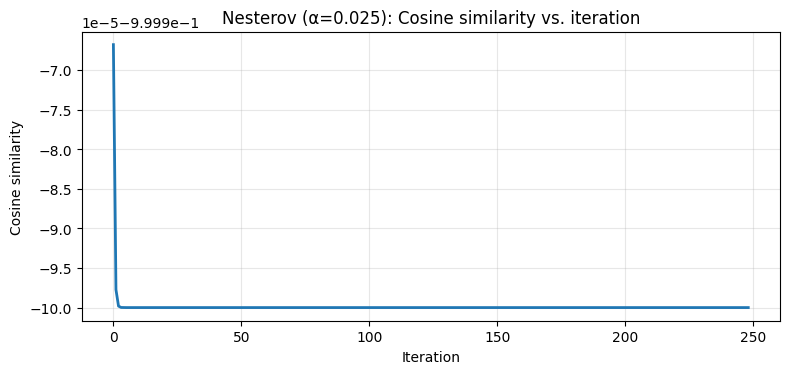

In [11]:
alpha_list = [0.005, 0.015, 0.025]

hists = {}

for alpha in alpha_list:
    hist = optimization(theta0, method="nesterov", alpha=alpha, beta=0.9)
    hists[f"Nesterov (α={alpha})"] = hist

min_len = min(len(v) for v in hists.values())

for name, hist in hists.items():
    plt.figure(figsize=(8, 4))
    
    y = np.asarray(hist[:min_len], dtype=float)
    plt.plot(np.arange(min_len), y, linewidth=2)
    
    plt.xlabel("Iteration")
    plt.ylabel("Cosine similarity")
    plt.title(f"{name}: Cosine similarity vs. iteration")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()